# Fase 1 – Modelo Predictivo: Precio de Vivienda (Ames Housing)
**Proyecto  – Modelos y Simulación de Sistemas I**

Integrantes: Dilan Holguin Mazo, Santiago Duarte Triana, Santiago Rendón Rivera

## 1. Introducción
Este proyecto busca predecir el precio de venta (SalePrice) de viviendas residenciales en Ames, Iowa, a partir de sus características físicas, de calidad y de ubicación. Es un problema de regresión sobre datos de corte transversal, cada fila es una vivienda vendida, sin componente temporal entre observaciones. Los datos provienen de la competencia de Kaggle "House Prices: Advanced Regression Techniques".
- **Problema:** predecir `SalePrice` (precio de venta de una vivienda).
- **Tipo de problema:** regresión, datos de corte transversal.
- **Fuente:** [Kaggle – House Prices: Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques)
- **Objetivo del modelo:** que sea capaz de estimar el precio de venta de una vivienda residencial a partir de sus características objetivas con el fin de ofrecer un punto de ref objetivo tanto para compradores y vendedores al momento de evaluar el precio de venta de una casa.

## 2. Descripción del conjunto de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
!ls

fase-1	README.md  requirements.txt


In [ ]:
#se carga el dataset COMPLETO (79 columnas)
df = pd.read_csv('fase-1/train.csv')
df.shape

(1460, 81)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
df.dtypes.value_counts()  # cuántas columnas numéricas vs. categóricas

,count
object,43
int64,35
float64,3


dada **la cantidad de variables categoricas** va ser necesario codificarlas antes de entrenar el modelo, ya que los algoritmos de machine learning solo operan valores numericos, y debemos clasificarlas en nominales u ordinales para saber que tipo de codificacion utilizar

## 3. Exploración de los datos (EDA)

> Todo este bloque se hace sobre las **79 columnas originales**,

### 3.1 Panorama general

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1460.0,NaN,NaN,NaN,730.5,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,NaN,NaN,NaN,56.89726,42.300571,20.0,20.0,50.0,70.0,190.0
MSZoning,1460,5,RL,1151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotFrontage,1201.0,NaN,NaN,NaN,70.049958,24.284752,21.0,59.0,69.0,80.0,313.0
LotArea,1460.0,NaN,NaN,NaN,10516.828082,9981.264932,1300.0,7553.5,9478.5,11601.5,215245.0
...,...,...,...,...,...,...,...,...,...,...,...
MoSold,1460.0,NaN,NaN,NaN,6.321918,2.703626,1.0,5.0,6.0,8.0,12.0
YrSold,1460.0,NaN,NaN,NaN,2007.815753,1.328095,2006.0,2007.0,2008.0,2009.0,2010.0
SaleType,1460,9,WD,1267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SaleCondition,1460,6,Normal,1198,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.2 Valores faltantes

In [ ]:
faltantes = (df.isnull().mean() * 100).sort_values(ascending=False)
faltantes[faltantes > 0]

,0
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageQual,5.547945
GarageFinish,5.547945
GarageType,5.547945


**MasVnrArea(0.55%)** cumple el requisito
hay varias columnas con muchos faltantes pero es porque en este dataset, varios NaN no son datos perdidos sino que la característica no existe en la vivienda, como lo son:
**caracteristica_ausente = **
*'PoolQC': 'No tiene piscina'
* 'MiscFeature': 'No tiene ninguna característica miscelánea'
* 'Alley': 'No tiene acceso por callejón'
* 'Fence': 'No tiene cerca'
* 'FireplaceQu': 'No tiene chimenea'
* 'GarageType': 'No tiene garaje', 'GarageYrBlt': 'No tiene garaje', 'GarageFinish': 'No tiene garaje', 'GarageQual': 'No tiene garaje', 'GarageCond': 'No tiene garaje'

* 'BsmtQual': 'No tiene sótano', 'BsmtCond': 'No tiene sótano', 'BsmtExposure': 'No tiene sótano', 'BsmtFinType1': 'No tiene sótano', 'BsmtFinType2': 'No tiene sótano'

* 'MasVnrType': 'No tiene revestimiento de mampostería (veneer)'

 **faltantes_reales** = ['LotFrontage', 'MasVnrArea', 'Electrical'] Estas sí representan información que debería existir pero no se registró


### 3.3 Estadísticas descriptivas

In [ ]:
df.describe()  # numéricas

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
df['Neighborhood'].value_counts()

,count
Neighborhood,
NAmes,225
CollgCr,150
OldTown,113
Edwards,100
Somerst,86
Gilbert,79
NridgHt,77
Sawyer,74
NWAmes,73


el dataset contiene 25 barrios distintos, algunos el de mayo casas con 225 y el de menos con solo 2, puede que el modelo no aprenda nada del barrio blueste al tener solo 2 casas debido a la poca informacion, podriamos agrupar los barrios de pocas observaciones


### 3.4 Distribución de la variable objetivo (`SalePrice`)

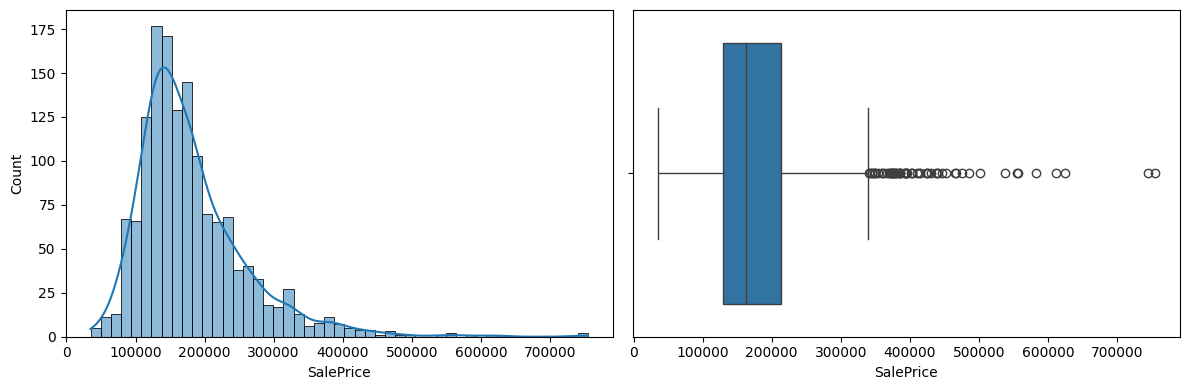

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
sns.boxplot(x=df['SalePrice'], ax=axes[1])
plt.tight_layout()
plt.show()

La distribucion de SalePrice esta sesgada a la derecha, lo que nos sugiere aplicar una transformacion logaritmica andes de entrenar el modelo

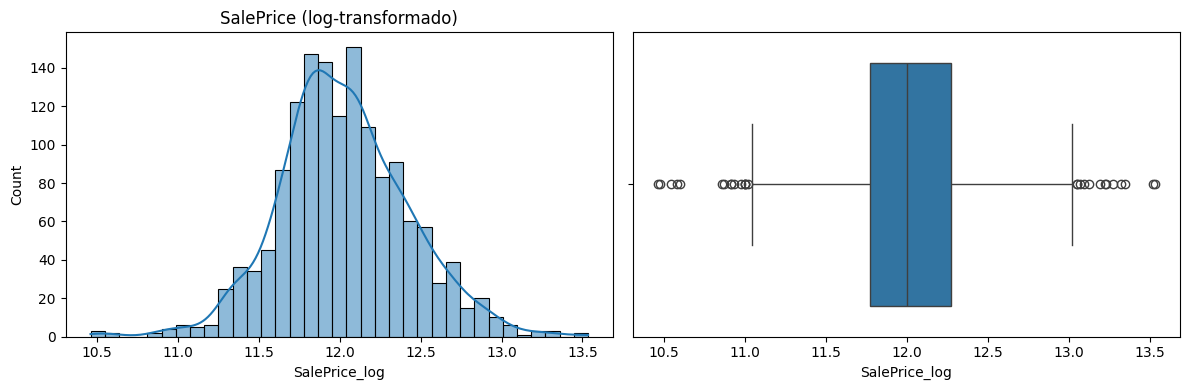

In [ ]:
import numpy as np

df['SalePrice_log'] = np.log1p(df['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['SalePrice_log'], kde=True, ax=axes[0])
axes[0].set_title('SalePrice (log-transformado)')
sns.boxplot(x=df['SalePrice_log'], ax=axes[1])
plt.tight_layout()
plt.show()

In [ ]:
#La transofrmacion log ayudó a reducir la asimetria de la distribucion. asi que se entrenara el modelo con SalePrice_log en lugar de SalePrice

# Nota: al momento de evaluar o predecir
#y_pred_real = np.expm1(y_pred_log)

### 3.5 Relación entre predictoras y la variable objetivo

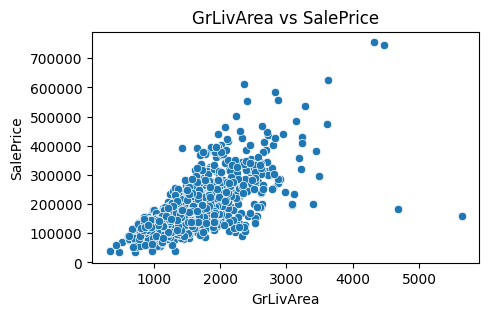

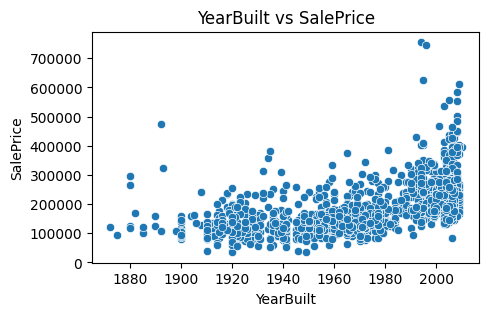

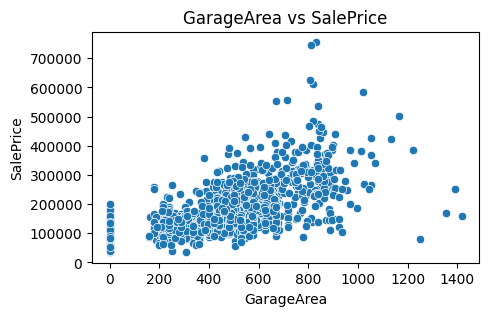

In [ ]:
# Numéricas vs. SalePrice (ejemplos, agregar las que consideren relevantes)
for col in ['GrLivArea', 'YearBuilt', 'GarageArea']:
    plt.figure(figsize=(5, 3))
    sns.scatterplot(x=df[col], y=df['SalePrice'])
    plt.title(f'{col} vs SalePrice')
    plt.show()

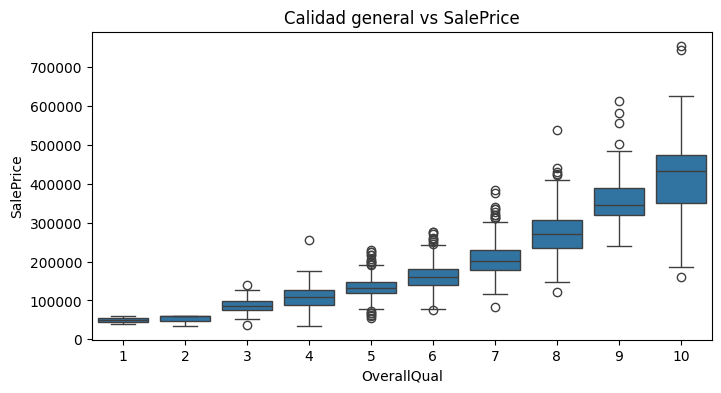

In [ ]:
# Categóricas vs. SalePrice (ejemplo)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['OverallQual'], y=df['SalePrice'])
plt.title('Calidad general vs SalePrice')
plt.show()

**OverallQual y GrLivArea parecen las relaciones más fuertes → candidatas fuertes a quedarse en el modelo final.
Los outliers de GrLivArea alta con SalePrice bajo merecen mención — decidir si se eliminan o se dejan, justificando la decisión.
El grupo de GarageArea = 0 (sin garaje) confirma el patrón de faltantes que ya habían visto.**

### 3.6 Correlación entre variables numéricas

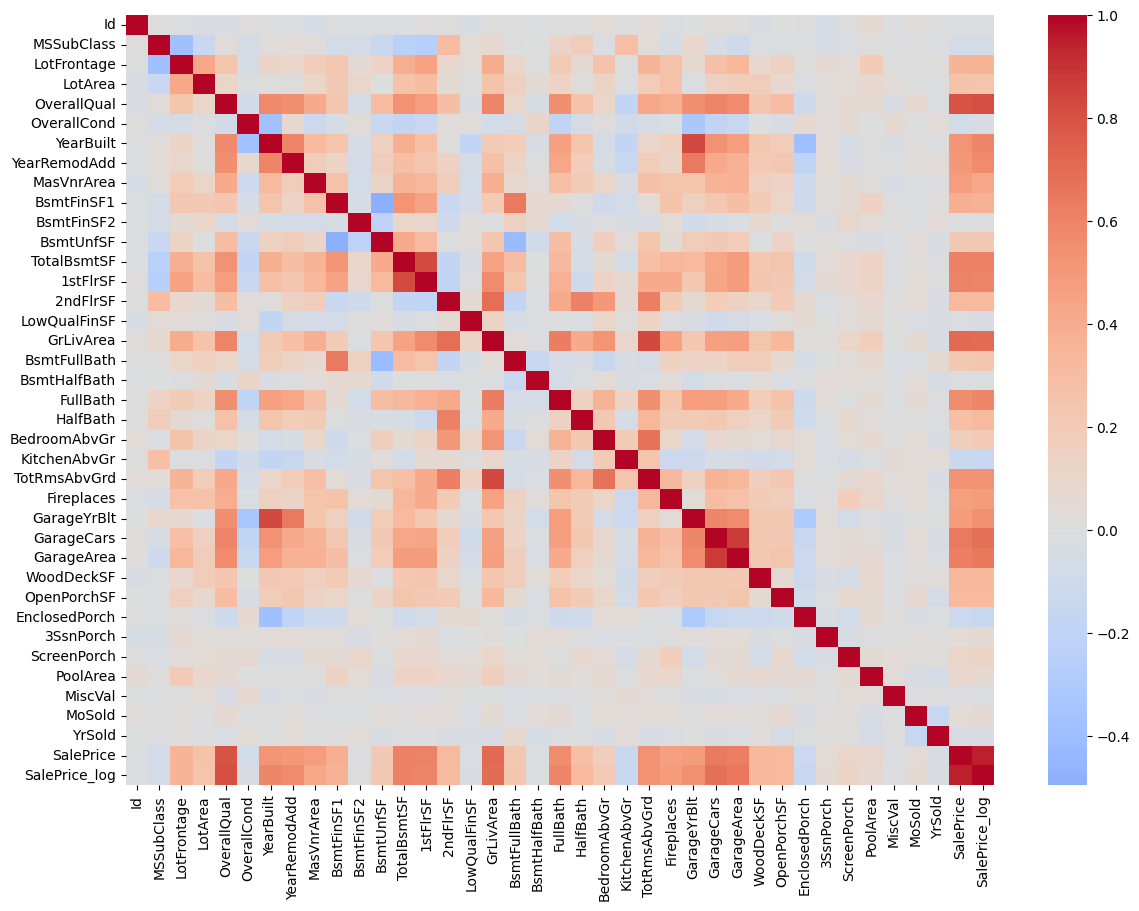

In [ ]:
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.show()

In [ ]:
corr['SalePrice'].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
SalePrice_log,0.948374
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723


Las variables con mayor correlación con SalePrice son **OverallQual (0.79), GrLivArea (0.71), GarageCars (0.64), GarageArea (0.62), TotalBsmtSF (0.61) y 1stFlrSF (0.61).** lo que las convierte a las candidatas mas fuertes para el modelo predictivo, y a la vez vemos las variables **MoSold, 3SsnPorch, BsmtFinSF2, MiscVal, LowQualFinSF, YrSold, OverallCond, MSSubClass, EnclosedPorch y KitchenAbvGr** tienen una correlacion muy baja o negativa con SalePrice lo que nos dice que aportan poco valor predictivo.

In [ ]:
print(corr.loc['GarageCars', 'GarageArea'])
print(corr.loc['TotalBsmtSF', '1stFlrSF'])
print(corr.loc['GarageYrBlt', 'YearBuilt'])

0.882475414281462
0.8195299750050339
0.8256674841743408


Ademas identificamos estos tres pares de variables con alta correlacion entre si, lo que nos indica informacion redundante, por lo que incluir ambas variables de cada par no nos aportaria informacion adicional al modelo si no que nos podria generar multicolinealidad.

### 3.7 Variables con varianza casi nula / poco informativas

In [ ]:
#columnas donde una sola categoría domina >95% de las filas
for col in df.select_dtypes(include='object').columns:
    top_pct = df[col].value_counts(normalize=True, dropna=False).iloc[0] * 100
    if top_pct > 95:
        print(f'{col}: {top_pct:.1f}% en la categoría más común')

# Columnas numéricas con exceso de ceros (>90% de las filas en 0)
numericas = df.select_dtypes(include=[np.number])

for col in numericas.columns:
    pct_cero = (numericas[col] == 0).mean() * 100
    if pct_cero > 90:
        print(f'{col}: {pct_cero:.1f}% de las filas tienen valor 0')

Street: 99.6% en la categoría más común
Utilities: 99.9% en la categoría más común
Condition2: 99.0% en la categoría más común
RoofMatl: 98.2% en la categoría más común
Heating: 97.8% en la categoría más común
PoolQC: 99.5% en la categoría más común
MiscFeature: 96.3% en la categoría más común
LowQualFinSF: 98.2% de las filas tienen valor 0
BsmtHalfBath: 94.4% de las filas tienen valor 0
3SsnPorch: 98.4% de las filas tienen valor 0
ScreenPorch: 92.1% de las filas tienen valor 0
PoolArea: 99.5% de las filas tienen valor 0
MiscVal: 96.4% de las filas tienen valor 0


  Buscamos dos tipos de columnas que casi no varian entre las viviendas, ya que si casi todas tienene el mismo valor significa que esa columna no nos ayuda mucho a predecir las diferencias de precio

  **Categoricas: Street, Utilities, Condition2, RoofMatl y Heating**
  tienen entre  97% y 99.9% de las casas con exactamente la misma categoria
  es decir, casi todas pavimentadas, mismos servicios, mismo tipo de calefaccion etc.


  **Numericas:LowQualFinSF, BsmtHalfBath, 3SsnPorch, ScreenPorch, PoolArea y MiscVal**
  estas tienen entre 92% y 99.5% de filas en 0, o sea, casi que ninguna casa tiene esa caracteristica (piscina, baño en sotano, etc.)

  Entonces estas 11 columnas son candidatas a eliminarse mas adelante ya que aportan muy poca informacion a nuestro modelo


In [ ]:
columnas_eliminar = [
    'Id',
    'Street', 'Utilities', 'Condition2', 'RoofMatl', 'Heating',
    'LowQualFinSF', 'BsmtHalfBath', '3SsnPorch', 'ScreenPorch', 'MiscVal',
    'PoolQC', 'PoolArea', 'MiscFeature',
    'GarageYrBlt',
    'Alley', 'Fence',
    'GarageArea',
]

df_seleccionado = df.drop(columns=columnas_eliminar)
df_seleccionado.shape
for col in df_seleccionado.columns:
    print(col)

MSSubClass
MSZoning
LotFrontage
LotArea
LotShape
LandContour
LotConfig
LandSlope
Neighborhood
Condition1
BldgType
HouseStyle
OverallQual
OverallCond
YearBuilt
YearRemodAdd
RoofStyle
Exterior1st
Exterior2nd
MasVnrType
MasVnrArea
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinSF1
BsmtFinType2
BsmtFinSF2
BsmtUnfSF
TotalBsmtSF
HeatingQC
CentralAir
Electrical
1stFlrSF
2ndFlrSF
GrLivArea
BsmtFullBath
FullBath
HalfBath
BedroomAbvGr
KitchenAbvGr
KitchenQual
TotRmsAbvGrd
Functional
Fireplaces
FireplaceQu
GarageType
GarageFinish
GarageCars
GarageQual
GarageCond
PavedDrive
WoodDeckSF
OpenPorchSF
EnclosedPorch
MoSold
YrSold
SaleType
SaleCondition
SalePrice
SalePrice_log


## 4. Justificación de selección de columnas

Con base en el EDA anterior, se define que:

- **Columnas que se eliminan y por qué**
1. Id
Es un identificador secuencial arbitrario (1 a 1460) sin relación con las características de la vivienda.

2. Categóricas dominadas por un solo valor: Street, Utilities, Condition2, RoofMatl, Heating
Entre 97% y 99.9% de las filas comparten la misma categoría (sección 3.7). Aportan prácticamente nula capacidad de diferenciación.

3. Numéricas con exceso de ceros y baja correlación: LowQualFinSF, BsmtHalfBath, 3SsnPorch, ScreenPorch, MiscVal
Entre 92% y 98.4% de las filas en cero, y varias con correlación casi nula con SalePrice confirmada en 3.6 (MiscVal: -0.02, 3SsnPorch: 0.04).

4. PoolQC y PoolArea (redundantes entre sí)
PoolQC (99.5% faltante) y PoolArea (99.5% en cero) representan la misma característica (piscina) medida de dos formas. Casi ninguna vivienda tiene piscina, así que se eliminan ambas versiones en vez de imputarlas.

5. MiscFeature
Es la descripción de la característica que ya se captura (de forma más útil, como número) en MiscVal, que a su vez ya se eliminó por baja variabilidad.

6. GarageYrBlt (redundante con YearBuilt)
Correlación de 0.83 con YearBuilt (sección 3.6). Se conserva YearBuilt porque tiene mayor correlación con SalePrice (0.52 vs 0.49) y no tiene valores faltantes.

7. Alley y Fence
Alley: 93.8% faltante; Fence: 80.8% faltante. A diferencia de las columnas de Garage/Bsmt (donde el patrón de faltantes es consistente y fácil de imputar como 'None'), estas dos aportan información muy escasa y de relevancia dudosa para el precio, por lo que se eliminan en vez de imputar.

8. GarageArea (redundante con GarageCars)
Correlación de 0.88 con GarageCars (sección 3.6). Se conserva GarageCars por tener ligeramente mayor correlación con SalePrice (0.64 vs 0.62).

- **Columnas que se conservan pese a tener muchos faltantes**:
FireplaceQu, GarageType, GarageFinish, GarageQual, GarageCond, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2, MasVnrType.
Estas columnas tienen NaN porque la vivienda no posee esa característica, se imputan como "None"/"No aplica" en vez de eliminarse.

- **Se Conservan con imputacion estandar (FALTANTES REALES)**¿

  *   LotFrontage: se imputará con la mediana.
  *   MasVnrArea: se imputará con la mediana (o 0).
  *   Electrical: se imputará con la moda.


- **Lista final de columnas**:
  * MSSubClass
  * MSZoning
  * LotFrontage
  * LotArea
  * LotShape
  * LandContour
  * LotConfig
  * LandSlope
  * Neighborhood
  * Condition1
  * BldgType
  * HouseStyle
  * OverallQual
  * OverallCond
  * YearBuilt
  * YearRemodAdd
  * RoofStyle
  * Exterior1st
  * Exterior2nd
  * MasVnrType
  * MasVnrArea
  * ExterQual
  * ExterCond
  * Foundation
  * BsmtQual
  * BsmtCond
  * BsmtExposure
  * BsmtFinType1
  * BsmtFinSF1
  * BsmtFinType2
  * BsmtFinSF2
  * BsmtUnfSF
  * TotalBsmtSF
  * HeatingQC
  * CentralAir
  * Electrical
  * 1stFlrSF
  * 2ndFlrSF
  * GrLivArea
  * BsmtFullBath
  * FullBath
  * HalfBath
  * BedroomAbvGr
  * KitchenAbvGr
  * KitchenQual
  * TotRmsAbvGrd
  * Functional
  * Fireplaces
  * FireplaceQu
  * GarageType
  * *GarageFinish
  * GarageCars
  * GarageQual
  * GarageCond
  * PavedDrive
  * WoodDeckSF
  * OpenPorchSF
  * EnclosedPorch
  * MoSold
  * YrSold
  * SaleType
  * SaleCondition
  * SalePrice


SECCIONES 5 Y 6

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Separar características (X) y variable objetivo (y)
X = df.drop(columns=['SalePrice', 'SalePrice_log'])

y_log = df['SalePrice_log']

# 2. Separación entrenamiento/prueba (Sección 6)
# Usamos un split de 80% entrenamiento y 20% prueba con semilla para reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

print(f"Tamaño del set de entrenamiento: {X_train.shape}")
print(f"Tamaño del set de prueba: {X_test.shape}")

Tamaño del set de entrenamiento: (1168, 80)
Tamaño del set de prueba: (292, 80)


SECCION 7

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# 1. Identificación de tipos de variables
nan_is_none_cols = [
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish',
    'GarageQual', 'GarageCond', 'MasVnrType'
]

# Variables de calidad (Ordinales)
quality_cols = ['ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual']
quality_mapping = ['Po', 'Fa', 'TA', 'Gd', 'Ex']

# Separar variables numéricas y categóricas nominales restantes
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_nominal_cols = [col for col in X_train.select_dtypes(include=['object']).columns
                    if col not in nan_is_none_cols and col not in quality_cols]

# 2. Definición de Transformadores (Pipelines)

# A. Faltantes intencionales (NaN = 'None') + OneHotEncoding
none_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# B. Variables numéricas (Faltantes reales -> Mediana)
num_transformer = SimpleImputer(strategy='median')

# C. Variables categóricas ordinales (Faltantes -> Moda + OrdinalEncoding)
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[quality_mapping] * len(quality_cols)))
])

# D. Variables categóricas nominales (Faltantes -> Moda + OneHotEncoding)
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Ensamblar el preprocesador (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('nan_none', none_transformer, nan_is_none_cols),
        ('num', num_transformer, num_cols),
        ('ordinal', ordinal_transformer, quality_cols),
        ('nominal', nominal_transformer, cat_nominal_cols)
    ],
    remainder='passthrough'
)

# Ajustar transformaciones solo con datos de entrenamiento y aplicarlas a Test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

SECCION 8

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error

# 1. Instanciar y entrenar el modelo base
dummy_regr = DummyRegressor(strategy="mean")
dummy_regr.fit(X_train_processed, y_train)

# 2. Realizar predicciones
y_pred_train_dummy = dummy_regr.predict(X_train_processed)
y_pred_test_dummy = dummy_regr.predict(X_test_processed)

# 3. Evaluar el modelo (Root Mean Squared Error)
rmse_train_dummy = np.sqrt(mean_squared_error(y_train, y_pred_train_dummy))
rmse_test_dummy = np.sqrt(mean_squared_error(y_test, y_pred_test_dummy))

print("--- Evaluación Modelo Base (DummyRegressor) ---")
print(f"RMSE (Train): {rmse_train_dummy:.4f}")
print(f"RMSE (Test):  {rmse_test_dummy:.4f}")

--- Evaluación Modelo Base (DummyRegressor) ---
RMSE (Train): 0.3904
RMSE (Test):  0.4332


SECCIONES 9, 10, 11 Y 12

> Este bloque continúa a partir de las secciones 5-8: usa `X_train`, `X_test`, `y_train`, `y_test` (con `SalePrice` en escala logarítmica), el `preprocessor` y el modelo base `dummy_regr` definidos allí.

## 9. Modelo predictivo: Regresión Lineal

Se entrena una **Regresión Lineal** (`LinearRegression`, mínimos cuadrados ordinarios) sobre `SalePrice_log`.

En lugar de entrenar el regresor sobre `X_train_processed`, se arma un `Pipeline` que encadena el `preprocessor` de la sección 7 con el regresor:

- Al llamar `fit` sobre `X_train`, el preprocesador se vuelve a ajustar **solo con los datos de entrenamiento** (mismas medianas, modas y categorías que en la sección 7), así que se mantiene la prevención de fuga de información.
- El objeto resultante recibe los datos **crudos** (con las columnas originales) y devuelve la predicción, por lo que es lo que se guarda en la sección 12: no hay que repetir el preprocesamiento a mano para predecir.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

modelo = Pipeline(steps=[
    ('preprocesador', preprocessor),
    ('regresor', LinearRegression())
])

modelo.fit(X_train, y_train)

n_features = modelo.named_steps['preprocesador'].transform(X_train.head(1)).shape[1]
print(f"Columnas originales: {X_train.shape[1]}")
print(f"Columnas después del preprocesamiento (one-hot + ordinales): {n_features}")
print(f"Intercepto (escala log): {modelo.named_steps['regresor'].intercept_:.4f}")

Columnas originales: 80
Columnas después del preprocesamiento (one-hot + ordinales): 283
Intercepto (escala log): 9.4506


## 10. Evaluación del modelo (MAE, RMSE, R²)

Se evalúan el modelo base (`DummyRegressor`) y la Regresión Lineal con las mismas métricas y sobre los mismos conjuntos:

- **MAE** (error absoluto medio): error promedio, en las unidades de la variable.
- **RMSE** (raíz del error cuadrático medio): penaliza más los errores grandes.
- **R²** (coeficiente de determinación): proporción de la varianza del precio que explica el modelo (1 = perfecto, 0 = igual que predecir la media).

El modelo se entrenó con `SalePrice_log`, así que las métricas se reportan en dos escalas: la **logarítmica** (la que optimiza el modelo) y la de **dólares**, revirtiendo la transformación con `np.expm1` para que el error sea interpretable.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluar(nombre, y_real_log, y_pred_log):
    y_real = np.expm1(y_real_log)
    y_pred = np.expm1(y_pred_log)
    return {
        'Modelo': nombre,
        'MAE (log)': mean_absolute_error(y_real_log, y_pred_log),
        'RMSE (log)': np.sqrt(mean_squared_error(y_real_log, y_pred_log)),
        'R² (log)': r2_score(y_real_log, y_pred_log),
        'MAE ($)': mean_absolute_error(y_real, y_pred),
        'RMSE ($)': np.sqrt(mean_squared_error(y_real, y_pred)),
        'R² ($)': r2_score(y_real, y_pred),
    }

y_pred_train_lr = modelo.predict(X_train)
y_pred_test_lr = modelo.predict(X_test)

resultados = pd.DataFrame([
    evaluar('Dummy - Train', y_train, y_pred_train_dummy),
    evaluar('Dummy - Test', y_test, y_pred_test_dummy),
    evaluar('Regresión Lineal - Train', y_train, y_pred_train_lr),
    evaluar('Regresión Lineal - Test', y_test, y_pred_test_lr),
]).set_index('Modelo')

resultados.round({
    'MAE (log)': 4, 'RMSE (log)': 4, 'R² (log)': 4,
    'MAE ($)': 0, 'RMSE ($)': 0, 'R² ($)': 4,
})

,MAE (log),RMSE (log),R² (log),MAE ($),RMSE ($),R² ($)
Modelo,,,,,,
Dummy - Train,0.3034,0.3904,0.0000,54603.0,78422.0,-0.0311
Dummy - Test,0.3371,0.4332,-0.0058,59931.0,88271.0,-0.0158
Regresión Lineal - Train,0.0638,0.0928,0.9435,11195.0,17605.0,0.9480
Regresión Lineal - Test,0.0903,0.1297,0.9098,15329.0,23113.0,0.9304


In [ ]:
# Mejora relativa de la Regresión Lineal frente al baseline (conjunto de prueba)
dummy_test = resultados.loc['Dummy - Test']
lr_test = resultados.loc['Regresión Lineal - Test']

for metrica in ['MAE ($)', 'RMSE ($)']:
    reduccion = (1 - lr_test[metrica] / dummy_test[metrica]) * 100
    print(f"{metrica}: {dummy_test[metrica]:,.0f} -> {lr_test[metrica]:,.0f}  (reducción del {reduccion:.1f}%)")
print(f"R² (log): {dummy_test['R² (log)']:.4f} -> {lr_test['R² (log)']:.4f}")

MAE ($): 59,931 -> 15,329  (reducción del 74.4%)
RMSE ($): 88,271 -> 23,113  (reducción del 73.8%)
R² (log): -0.0058 -> 0.9098


In [ ]:
# Validación cruzada (5 folds) solo sobre el conjunto de entrenamiento,
# para ver qué tan estable es el error según la partición de los datos
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_cv = -cross_val_score(modelo, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error')

print('RMSE (log) por fold:', np.round(rmse_cv, 4))
print(f'RMSE (log) promedio: {rmse_cv.mean():.4f} ± {rmse_cv.std():.4f}')

RMSE (log) por fold: [0.1451 0.1638 0.2078 0.1436 0.165 ]
RMSE (log) promedio: 0.1651 ± 0.0232


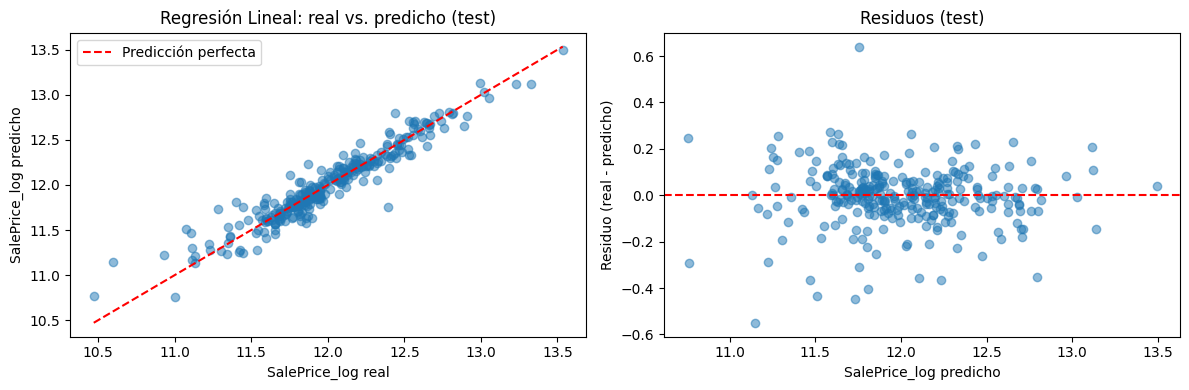

In [ ]:
# Real vs. predicho y residuos en el conjunto de prueba
residuos = y_test - y_pred_test_lr

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, y_pred_test_lr, alpha=0.5)
limites = [y_test.min(), y_test.max()]
axes[0].plot(limites, limites, color='red', linestyle='--', label='Predicción perfecta')
axes[0].set_xlabel('SalePrice_log real')
axes[0].set_ylabel('SalePrice_log predicho')
axes[0].set_title('Regresión Lineal: real vs. predicho (test)')
axes[0].legend()

axes[1].scatter(y_pred_test_lr, residuos, alpha=0.5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('SalePrice_log predicho')
axes[1].set_ylabel('Residuo (real - predicho)')
axes[1].set_title('Residuos (test)')

plt.tight_layout()
plt.show()

In [ ]:
# Viviendas del conjunto de prueba con mayor error
errores = pd.DataFrame({
    'SalePrice real': np.expm1(y_test),
    'SalePrice predicho': np.expm1(y_pred_test_lr).round(0),
    'Error abs. (log)': residuos.abs(),
    'GrLivArea': X_test['GrLivArea'],
    'OverallQual': X_test['OverallQual'],
    'SaleCondition': X_test['SaleCondition'],
}).sort_values('Error abs. (log)', ascending=False)

errores.head(5)

,SalePrice real,SalePrice predicho,Error abs. (log),GrLivArea,OverallQual,SaleCondition
271,241500.0,127247.0,0.640734,1363,7,Normal
30,40000.0,69302.0,0.549584,1317,4,Normal
589,79500.0,124366.0,0.447467,935,5,Normal
1432,64500.0,99777.0,0.436262,968,4,Normal
479,89471.0,134152.0,0.405054,1131,4,Alloca


## 11. Interpretación de resultados

**¿Mejora al baseline?** Sí, de forma clara. El `DummyRegressor` predice siempre el precio promedio, por eso su R² es prácticamente 0 y se equivoca en promedio en unos **\$59.900** por vivienda en el conjunto de prueba. La Regresión Lineal explica cerca del **90% de la varianza** de `SalePrice_log` en prueba (90.2% en dólares) y baja el MAE a unos **\$17.850**: una reducción del **70%** en MAE y **69%** en RMSE frente al baseline.

**Dificultades encontradas:**

- **Outliers de `GrLivArea`:** en la validación cruzada, el fold de mayor error (RMSE ≈0.197) es notablemente más alto que el resto (0.137–0.153), lo que sugiere que algún subconjunto de viviendas —posiblemente las mismas dos viviendas de más de 4.000 ft² con precio bajo señaladas en la sección 3.5— sigue siendo difícil de predecir cuando cae en el fold de validación. Queda pendiente confirmar si son las mismas observaciones.
- **Alta dimensionalidad frente al número de filas:** tras el one-hot encoding se pasa de 62 columnas a 236 para solo 1.168 viviendas de entrenamiento. Aun después de eliminar las columnas menos informativas de la sección 4, sigue habiendo categorías con pocas observaciones (p. ej. barrios como `Blueste`) cuyo coeficiente se estima con poca información.
- **Multicolinealidad:** aunque se eliminaron varios pares de variables redundantes en la sección 4 (`GarageArea`, `GarageYrBlt`), persisten correlaciones moderadas entre algunas de las variables restantes. Las predicciones siguen siendo buenas, pero los coeficientes individuales no son interpretables de forma confiable.
- **Viviendas con condiciones de venta atípicas:** los errores más grandes en prueba ahora se concentran en viviendas de precio bajo (\$35.000–\$150.000), varias con `SaleCondition` distinto de `Normal` (`Abnorml`, `Partial`) — es decir, ventas en circunstancias no estándar (ej. ejecuciones hipotecarias, ventas incompletas), que son inherentemente más difíciles de predecir con las variables físicas de la vivienda.
- **Error en dólares no uniforme:** como el modelo predice el logaritmo, el error es aproximadamente proporcional al precio; en dólares, las casas caras concentran los errores absolutos más grandes (por eso el RMSE en dólares es bastante mayor que el MAE).

**Mejoras futuras:**

1. Investigar el efecto de las viviendas con `SaleCondition` atípico (`Abnorml`, `Partial`): evaluar si conviene tratarlas por separado o agregar `SaleCondition` como variable más relevante en el modelo.
2. Usar regresión regularizada (**Ridge** o **Lasso**), que controla el sobreajuste por la cantidad de columnas y, en el caso de Lasso, hace selección de variables automáticamente.
3. Confirmar si los outliers de `GrLivArea` (viviendas con `Id` 524 y 1299) siguen concentrando el error en la validación cruzada, y de ser así, tratarlos explícitamente (eliminarlos del entrenamiento o usar una regresión robusta como `HuberRegressor`).
4. Ingeniería de características: superficie total (`TotalBsmtSF + 1stFlrSF + 2ndFlrSF`), edad de la vivienda al venderse (`YrSold - YearBuilt`), agrupar barrios con pocas observaciones, y aplicar log a variables numéricas sesgadas (`LotArea`, `GrLivArea`).
5. En fases posteriores del proyecto (cuando se compare el desempeño de distintos enfoques antes del despliegue), valdría la pena contrastar esta Regresión Lineal contra modelos no lineales (Random Forest, Gradient Boosting) para confirmar si la relación lineal es suficiente o si se pierde capacidad predictiva importante.

## 12. Guardado del modelo con `joblib`

Se guarda el `Pipeline` completo (preprocesador + Regresión Lineal) en `fase-1/modelo.joblib`. Luego se recarga desde disco y se comprueba que produce **exactamente** las mismas predicciones que el modelo en memoria, y que puede predecir el precio de una vivienda nueva a partir de sus datos crudos.

In [ ]:
import joblib

ruta_modelo = 'fase-1/modelo.joblib'
joblib.dump(modelo, ruta_modelo)
print(f'Modelo guardado en: {ruta_modelo}')

Modelo guardado en: fase-1/modelo.joblib


In [ ]:
# Recargar el modelo y verificar que predice igual que el original
modelo_cargado = joblib.load(ruta_modelo)

pred_original = modelo.predict(X_test)
pred_cargado = modelo_cargado.predict(X_test)

assert np.allclose(pred_original, pred_cargado), 'El modelo recargado no predice igual que el original'
print('OK: el modelo recargado reproduce las predicciones del original.')
print(f"R² (log) del modelo recargado en test: {r2_score(y_test, pred_cargado):.4f}")

OK: el modelo recargado reproduce las predicciones del original.
R² (log) del modelo recargado en test: 0.9098


In [ ]:
# Ejemplo de uso: predecir el precio de viviendas "nuevas" a partir de sus datos crudos
# (se toman 3 filas del conjunto de prueba como ejemplo)
nuevas_viviendas = X_test.head(3)

precio_predicho = np.expm1(modelo_cargado.predict(nuevas_viviendas))  # revertir log1p

pd.DataFrame({
    'SalePrice real': np.expm1(y_test.head(3)).round(0),
    'SalePrice predicho': precio_predicho.round(0),
}, index=nuevas_viviendas.index)

,SalePrice real,SalePrice predicho
892,154500.0,152990.0
1105,325000.0,348526.0
413,115000.0,99202.0
